# EDA - Teen Mental Health Dataset

Este notebook presenta un analisis exploratorio del dataset `Teen_Mental_Health_Dataset.csv`. El objetivo es estudiar la relacion entre habitos digitales, sueno, actividad fisica, rendimiento academico y la variable objetivo `depression_label`.

El analisis parte del borrador inicial y lo reorganiza en un flujo reproducible: carga de datos, validacion, limpieza, feature engineering, visualizacion y contraste estadistico basico.


## 1. Importacion de librerias y configuracion


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.cleaning import clean_data, detect_outliers_iqr
from src.features import build_features
from src.io import load_data, save_data
from src.utils import chi_square_report, missing_values_report
from src.viz import (
    plot_correlation_matrix,
    plot_depression_rate_by_category,
    plot_depression_vs_social_media,
    plot_numeric_distributions,
)

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Teen_Mental_Health_Dataset.csv"
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "teen_mental_health_processed.csv"

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)


## 2. Carga de datos

Se carga el CSV original desde `data/raw`. Esta version se mantiene sin modificar para conservar una fuente de datos reproducible.


In [2]:
df_raw = load_data(RAW_DATA_PATH)
df_raw.head()


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [3]:
print(f"Filas: {df_raw.shape[0]}")
print(f"Columnas: {df_raw.shape[1]}")
df_raw.info()


Filas: 1200
Columnas: 13
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 140

## 3. Validacion inicial

Antes de transformar el dataset se revisan columnas, nulos y duplicados. En esta muestra no aparecen valores nulos ni registros duplicados, pero se mantiene el paso de limpieza dentro del pipeline para que el proyecto sea robusto.


In [4]:
df_raw.columns.tolist()


['age',
 'gender',
 'daily_social_media_hours',
 'platform_usage',
 'sleep_hours',
 'screen_time_before_sleep',
 'academic_performance',
 'physical_activity',
 'social_interaction_level',
 'stress_level',
 'anxiety_level',
 'addiction_level',
 'depression_label']

In [5]:
missing_values_report(df_raw)


,missing_values,missing_pct
age,0,0.0
gender,0,0.0
daily_social_media_hours,0,0.0
platform_usage,0,0.0
sleep_hours,0,0.0
screen_time_before_sleep,0,0.0
academic_performance,0,0.0
physical_activity,0,0.0
social_interaction_level,0,0.0
stress_level,0,0.0


In [6]:
print(f"Duplicados: {df_raw.duplicated().sum()}")


Duplicados: 0


## 4. Limpieza y feature engineering

Se normalizan nombres de columnas, se convierten variables categoricas y se crean variables derivadas:

- `heavy_social_media_user`: marca usuarios con 5 o mas horas diarias en redes sociales.
- `sleep_quality`: clasifica el sueno en `poor`, `normal` y `good`.
- `risk_score`: indicador sintetico basado en redes sociales, sueno y rendimiento academico.
- `risk_category`: terciles de `risk_score`.


In [7]:
df = clean_data(df_raw)
df = build_features(df)
save_data(df, PROCESSED_DATA_PATH)

df.head()


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,heavy_social_media_user,sleep_quality,risk_score,risk_category
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0,1,good,3.037,high
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0,0,good,0.394,low
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0,0,good,0.064,low
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0,1,normal,2.846,high
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0,0,poor,2.699,high


In [8]:
print(f"Dataset procesado guardado en: {PROCESSED_DATA_PATH}")
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
df.dtypes


Dataset procesado guardado en: /Users/jobdelgadoiniesta/Documents/EVOLVE/proyecto-github-01/data/processed/teen_mental_health_processed.csv
Filas: 1200 | Columnas: 17


age                            int64
gender                      category
daily_social_media_hours     float64
platform_usage              category
sleep_hours                  float64
screen_time_before_sleep     float64
academic_performance         float64
physical_activity            float64
social_interaction_level    category
stress_level                   int64
anxiety_level                  int64
addiction_level                int64
depression_label               int64
heavy_social_media_user        int64
sleep_quality               category
risk_score                   float64
risk_category               category
dtype: object

## 5. Analisis descriptivo

Se revisan estadisticos generales de las variables numericas y la distribucion de la variable objetivo. El porcentaje de positivos en `depression_label` es bajo, por lo que cualquier comparacion debe interpretarse teniendo en cuenta el desbalance.


In [9]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,1200.0,15.928333,2.021947,13.00,14.00000,16.000,18.00000,19.000
daily_social_media_hours,1200.0,4.536667,2.029599,1.00,2.80000,4.500,6.30000,8.000
sleep_hours,1200.0,6.449417,1.442677,4.00,5.20000,6.500,7.60000,9.000
screen_time_before_sleep,1200.0,1.740333,0.716660,0.50,1.10000,1.800,2.40000,3.000
academic_performance,1200.0,2.990383,0.576758,2.00,2.50000,2.990,3.48000,4.000
physical_activity,1200.0,1.014500,0.582185,0.00,0.50000,1.000,1.50000,2.000
stress_level,1200.0,5.445833,2.903290,1.00,3.00000,5.000,8.00000,10.000
anxiety_level,1200.0,5.636667,2.859453,1.00,3.00000,6.000,8.00000,10.000
addiction_level,1200.0,5.565000,2.830627,1.00,3.00000,6.000,8.00000,10.000
depression_label,1200.0,0.025833,0.158704,0.00,0.00000,0.000,0.00000,1.000


In [10]:
target_distribution = (
    df["depression_label"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("percentage")
    .to_frame()
)
target_distribution


,percentage
depression_label,
0,97.416667
1,2.583333


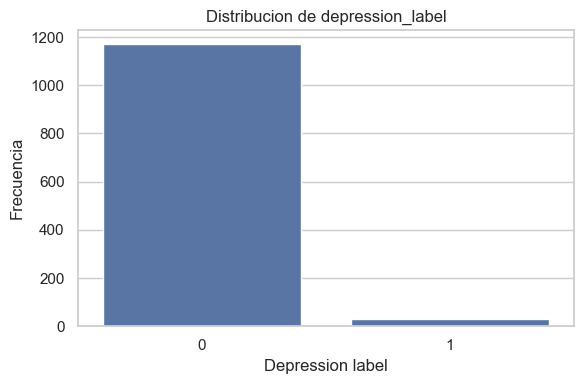

In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="depression_label")
plt.title("Distribucion de depression_label")
plt.xlabel("Depression label")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


## 6. Distribuciones numericas

Los histogramas permiten detectar rangos, concentraciones y posibles variables con distribuciones poco uniformes.


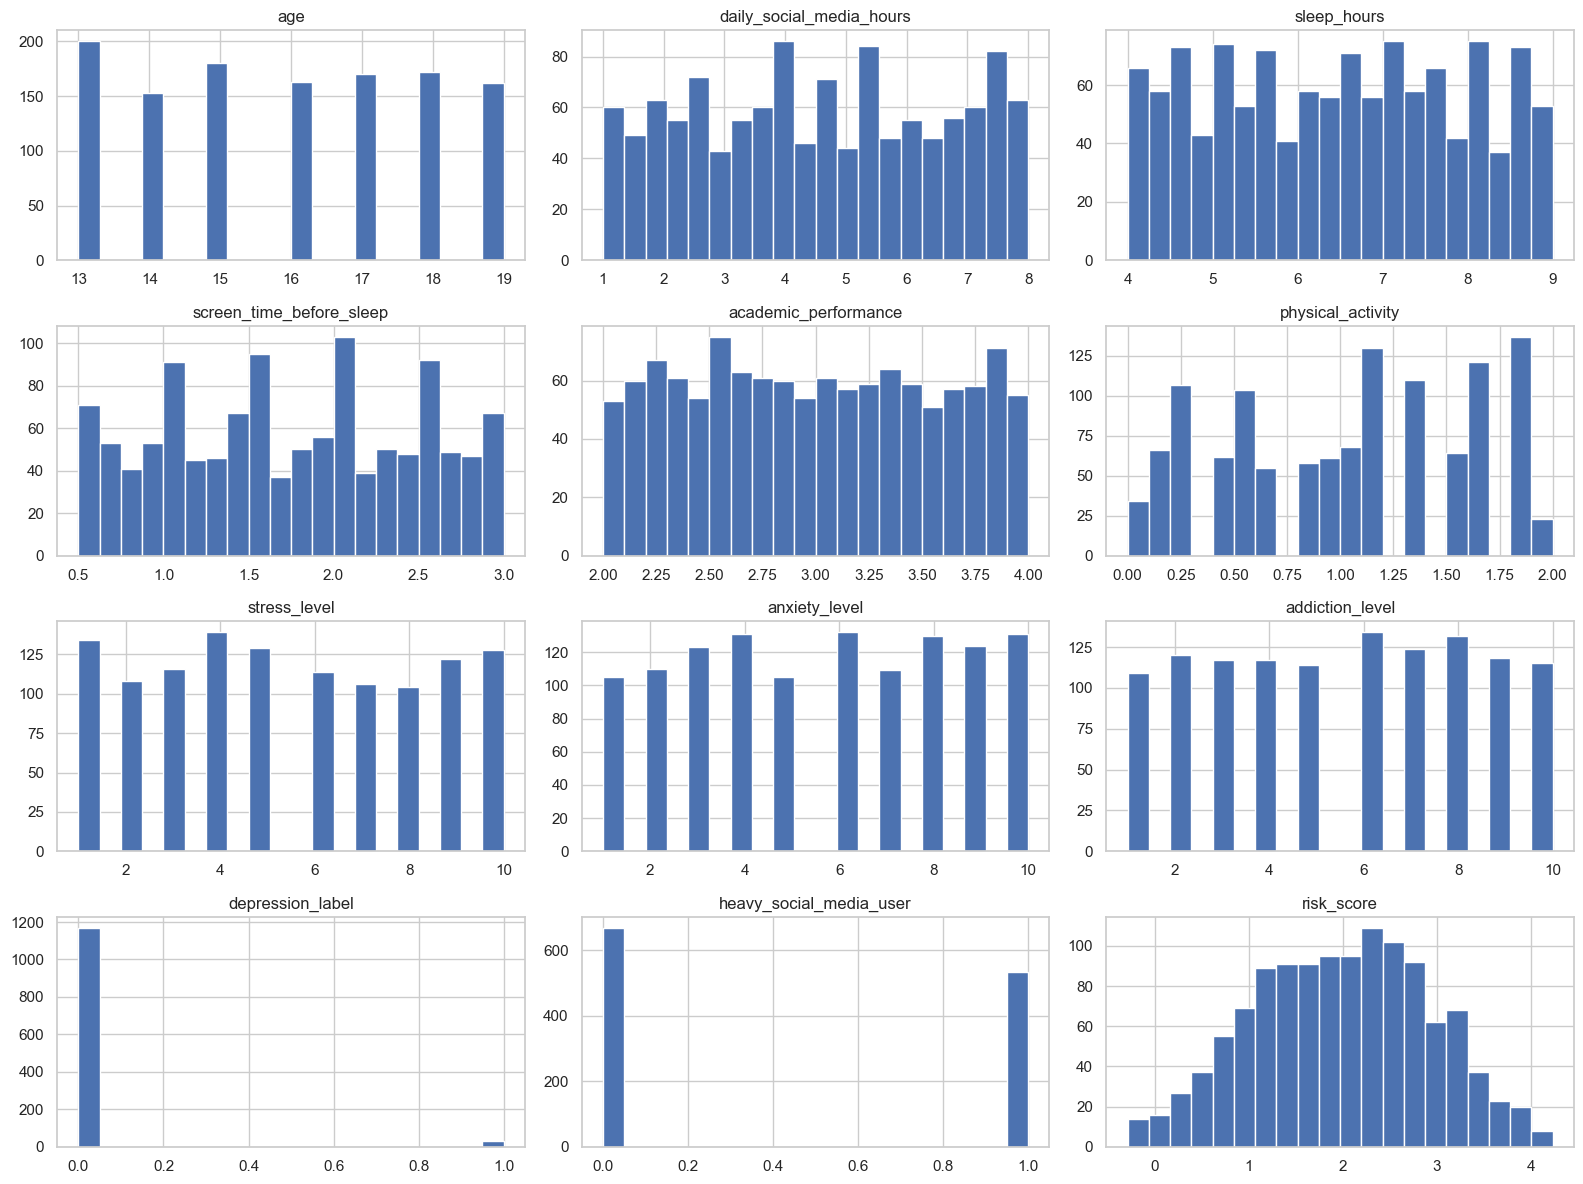

In [12]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
plot_numeric_distributions(df, numeric_cols)


## 7. Variables categoricas

Se revisa la frecuencia de genero, plataforma principal y nivel de interaccion social.


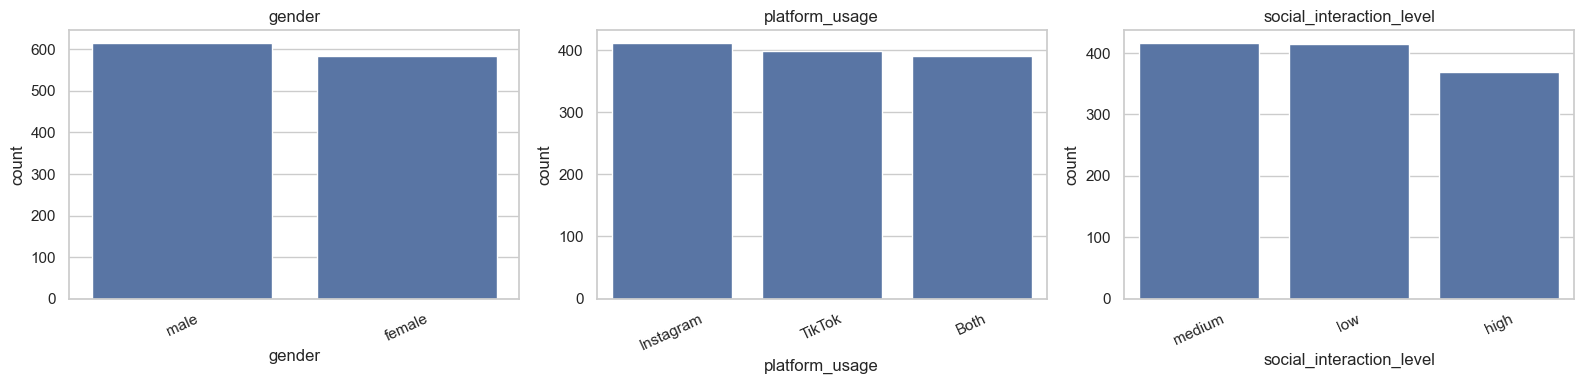

In [13]:
categorical_cols = ["gender", "platform_usage", "social_interaction_level"]

fig, axes = plt.subplots(1, len(categorical_cols), figsize=(16, 4))

for ax, col in zip(axes, categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


## 8. Correlaciones

La matriz de correlacion ayuda a observar asociaciones lineales entre variables numericas. No implica causalidad, pero orienta el analisis posterior.


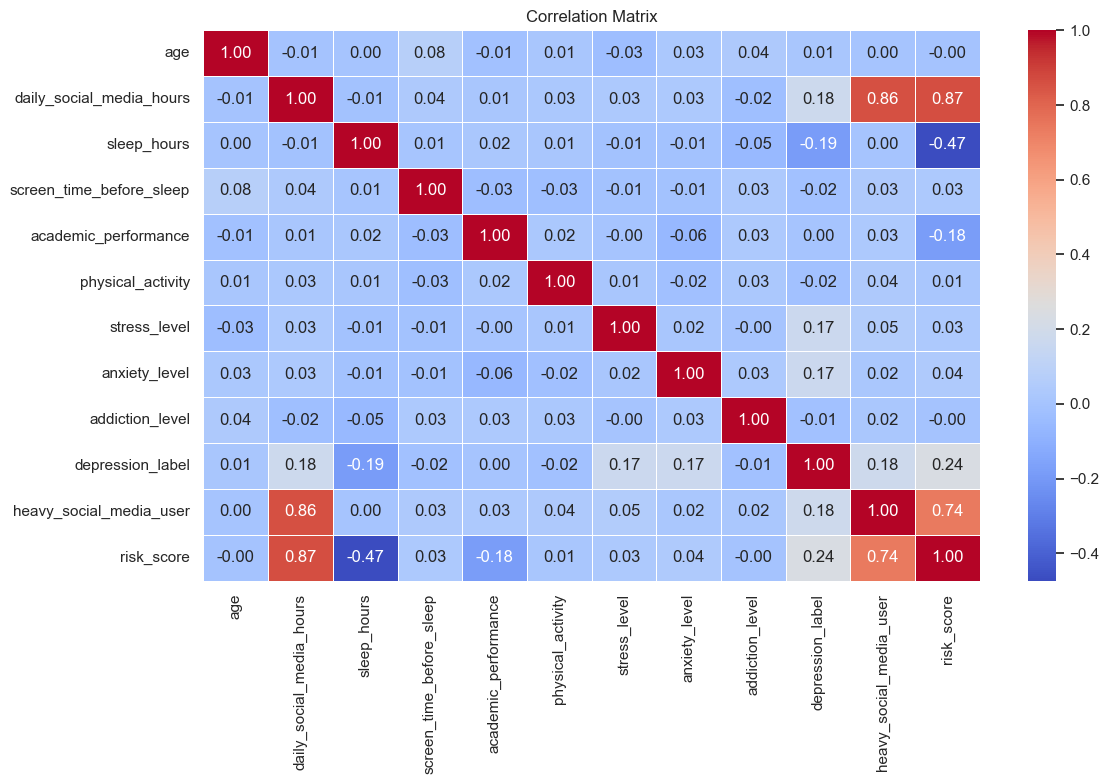

In [14]:
plot_correlation_matrix(df, numeric_cols)


In [15]:
(
    df[numeric_cols]
    .corr()["depression_label"]
    .sort_values(ascending=False)
    .to_frame("correlation_with_depression_label")
)


,correlation_with_depression_label
depression_label,1.000000
risk_score,0.238959
heavy_social_media_user,0.182476
daily_social_media_hours,0.175201
stress_level,0.170474
anxiety_level,0.169566
age,0.010973
academic_performance,0.001441
addiction_level,-0.013952
screen_time_before_sleep,-0.016502


## 9. Relacion entre variables numericas y depression_label

Se comparan algunas variables clave frente a la etiqueta de depresion: uso diario de redes sociales, horas de sueno, estres y ansiedad.


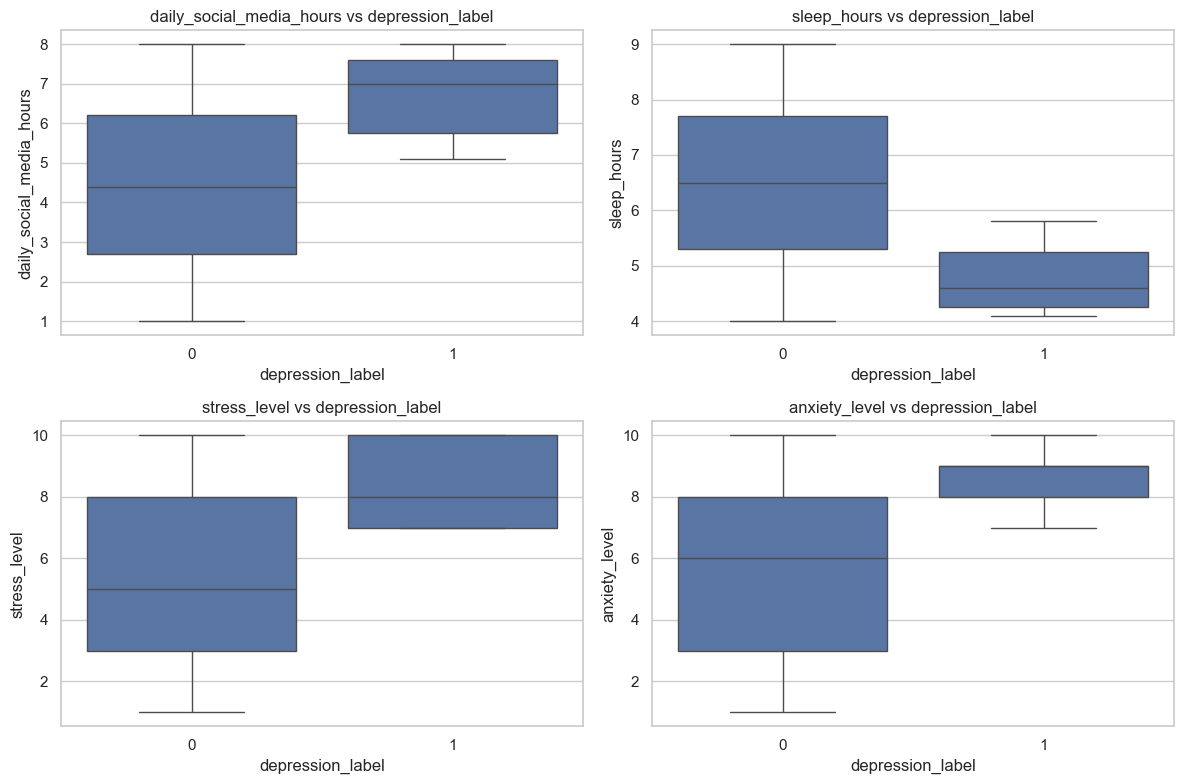

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
variables_to_compare = [
    "daily_social_media_hours",
    "sleep_hours",
    "stress_level",
    "anxiety_level",
]

for ax, col in zip(axes.ravel(), variables_to_compare):
    sns.boxplot(data=df, x="depression_label", y=col, ax=ax)
    ax.set_title(f"{col} vs depression_label")

plt.tight_layout()
plt.show()


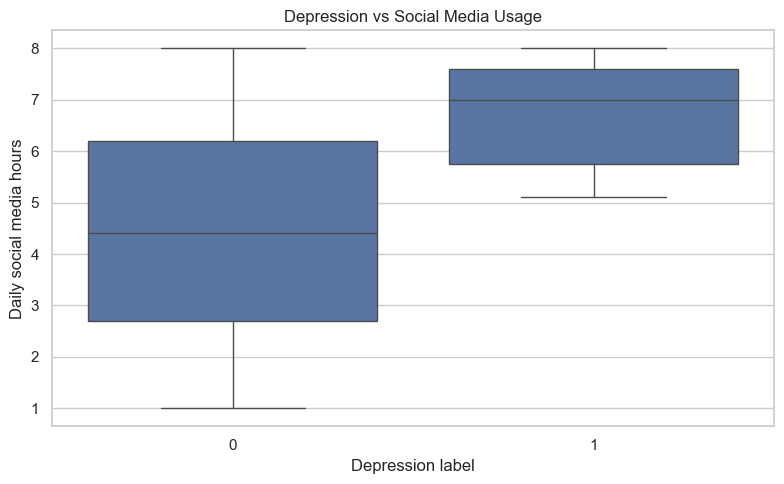

In [17]:
plot_depression_vs_social_media(df)


## 10. Relacion entre variables categoricas y depression_label

Se calcula la tasa media de `depression_label` por categoria y se contrastan asociaciones con chi-cuadrado y Cramer's V.


In [18]:
for col in categorical_cols:
    display(
        df.groupby(col, observed=True)["depression_label"]
        .agg(["mean", "count"])
        .sort_values("mean", ascending=False)
    )


,mean,count
gender,,
female,0.029060,585
male,0.022764,615


,mean,count
platform_usage,,
TikTok,0.030151,398
Instagram,0.024331,411
Both,0.023018,391


,mean,count
social_interaction_level,,
medium,0.028846,416
high,0.027100,369
low,0.021687,415


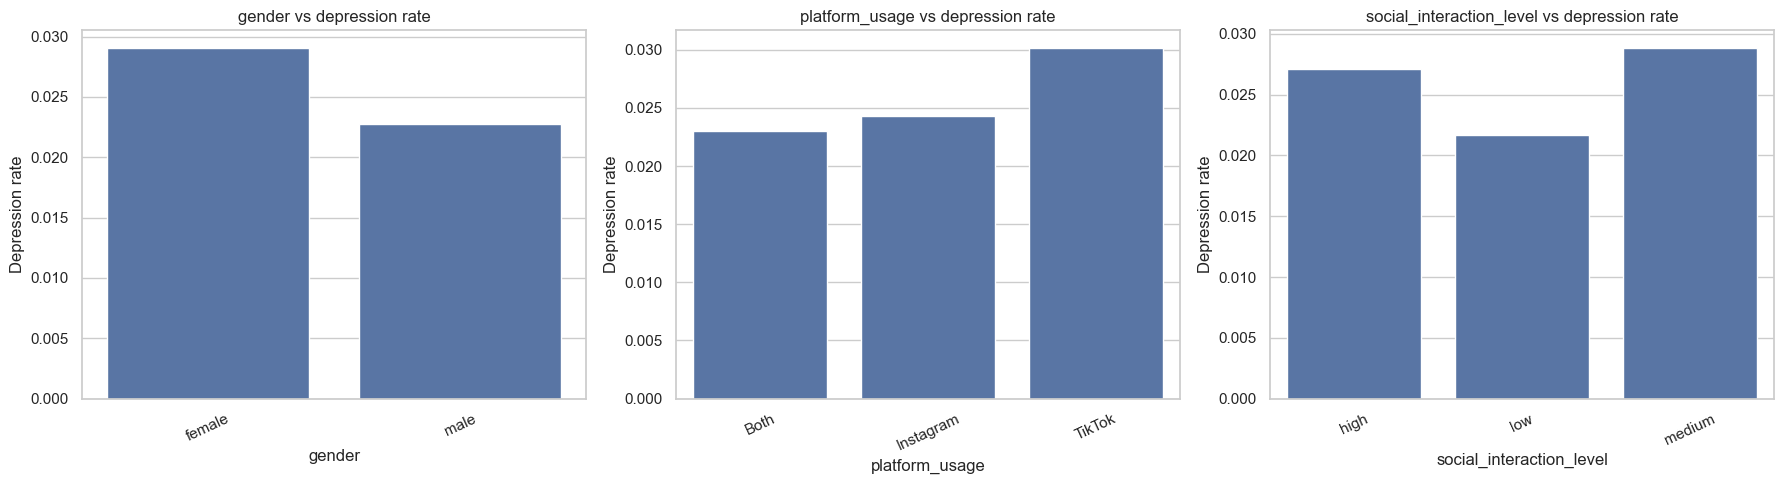

In [19]:
plot_depression_rate_by_category(df, categorical_cols)


In [20]:
chi_square_report(df, categorical_cols, "depression_label")


,feature,chi2,p_value,dof,cramers_v
2,social_interaction_level,0.457123,0.795677,2,0.019518
1,platform_usage,0.454814,0.796596,2,0.019468
0,gender,0.255154,0.613469,1,0.014582


## 11. Outliers

Se revisan outliers con el metodo IQR en variables numericas principales. En este contexto no se eliminan automaticamente: primero conviene decidir si representan errores o casos reales.


In [21]:
outlier_summary = []

for col in numeric_cols:
    outliers = detect_outliers_iqr(df, col)
    outlier_summary.append({"feature": col, "outliers": len(outliers)})

pd.DataFrame(outlier_summary).sort_values("outliers", ascending=False)


,feature,outliers
9,depression_label,31
0,age,0
1,daily_social_media_hours,0
2,sleep_hours,0
3,screen_time_before_sleep,0
4,academic_performance,0
5,physical_activity,0
6,stress_level,0
7,anxiety_level,0
8,addiction_level,0


## 12. Conclusiones

- El dataset tiene 1200 registros y 13 variables originales; tras feature engineering se incorporan variables derivadas para facilitar el analisis.
- No se observan nulos ni duplicados en la version revisada.
- `depression_label` esta desbalanceada: los positivos representan aproximadamente un 2.6% de la muestra.
- Las asociaciones lineales mas visibles con `depression_label` son: mayor uso diario de redes sociales, mayor estres, mayor ansiedad y menos horas de sueno.
- Las variables categoricas revisadas no muestran una asociacion fuerte con `depression_label` segun chi-cuadrado y Cramer's V.
- Los resultados son exploratorios y no deben interpretarse como causalidad.
